In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

from google.colab import drive
drive.mount("/content/drive")

import warnings
warnings.filterwarnings("ignore")

Mounted at /content/drive


# **SEASONAL DATASET**

In [3]:
file_path = "/content/drive/MyDrive/Colab Notebooks/CSV DATASET FILES/test.csv"
df = pd.read_csv(file_path, parse_dates = ["Date"], index_col = "Date")
df

,store,product,number_sold
Date,,,
2019-01-01,0,0,845
2019-01-02,0,0,851
2019-01-03,0,0,840
2019-01-04,0,0,842
2019-01-05,0,0,845
...,...,...,...
2019-12-27,6,9,901
2019-12-28,6,9,926
2019-12-29,6,9,913


In [4]:
# Data preprocessing
df = df.drop(columns = ["store","product"])

# Aggregating duplicates
df = df.groupby(df.index).sum()
df.index = pd.to_datetime(df.index)
#  df = df.asfreq("MS")

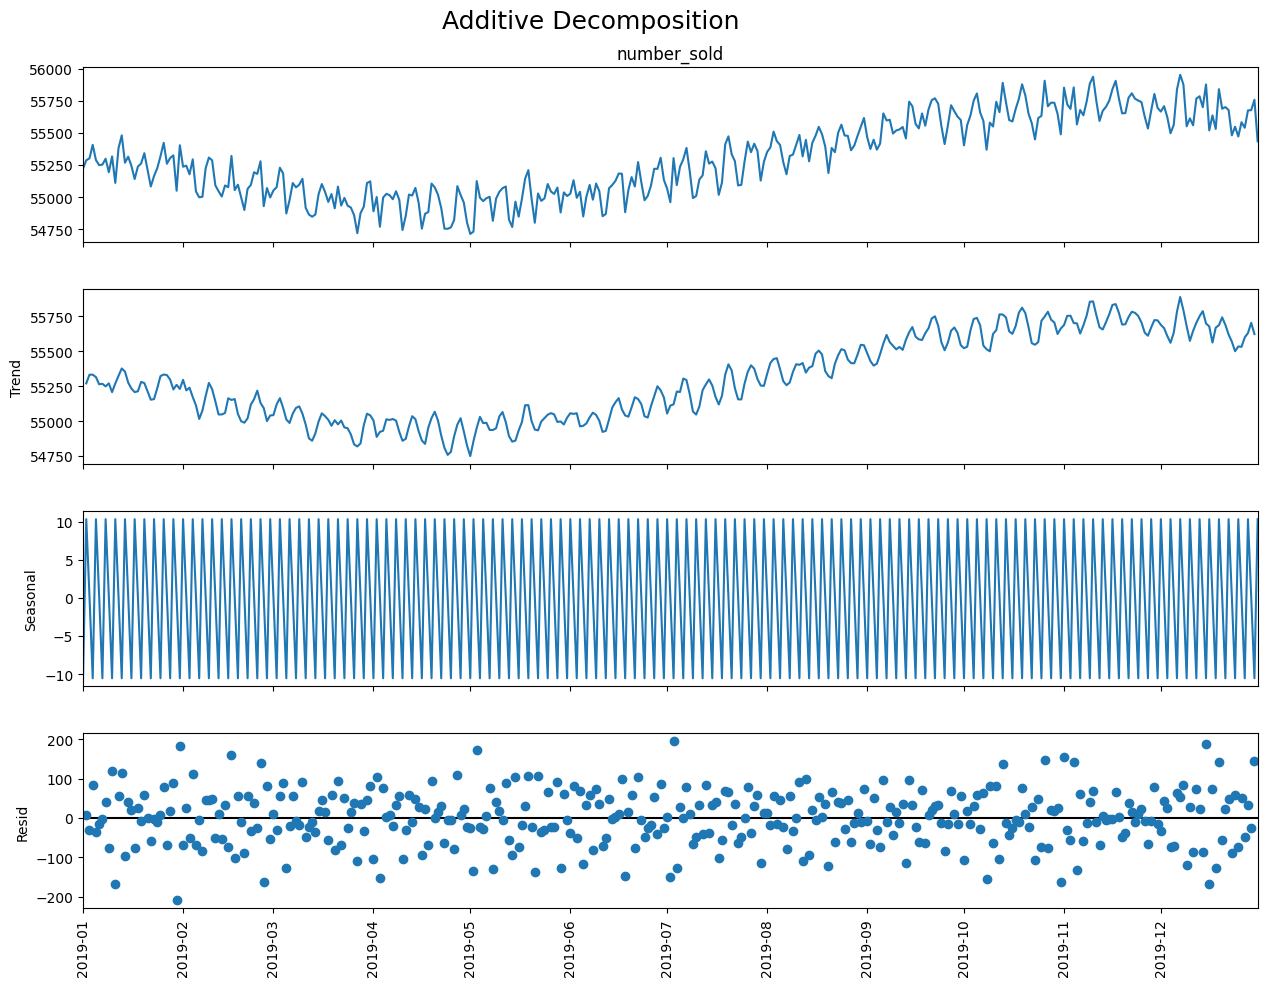

In [5]:
# Applying Additive Decomposition
additive_result = seasonal_decompose(df["number_sold"], model="additive", period = 3)

fig = additive_result.plot()
fig.set_size_inches(14, 10)
plt.suptitle("Additive Decomposition", fontsize=18)
plt.xticks(rotation=90)
plt.show()

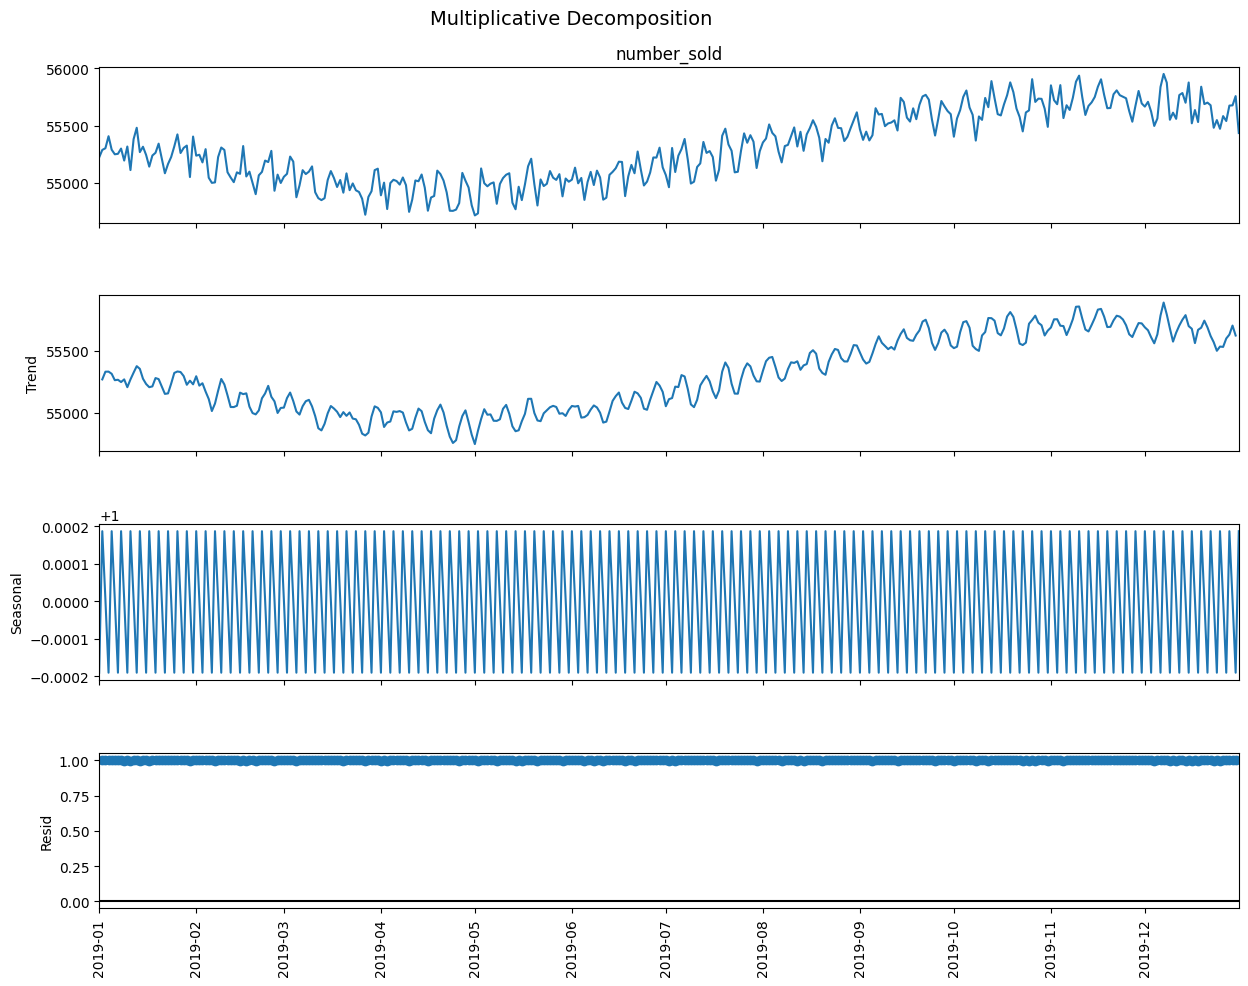

In [6]:
# Applying Multiplicative Decomposition
multiplicative_result = seasonal_decompose(df["number_sold"], model='multiplicative', period = 3)

fig = multiplicative_result.plot()
fig.set_size_inches(14, 10)
plt.suptitle("Multiplicative Decomposition", fontsize=14)
plt.xticks(rotation = 90)
plt.show()

# **TRENDS DATASET**

In [7]:
file_path = "/content/drive/MyDrive/Colab Notebooks/CSV DATASET FILES/AirPassengers.csv"
df = pd.read_csv(file_path, index_col = "Month")
df

,Passengers
Month,
1949-01,112
1949-02,118
1949-03,132
1949-04,129
1949-05,121
...,...
1960-08,606
1960-09,508
1960-10,461


In [8]:
# Data preprocessing
# Aggregating duplicates
df = df.groupby(df.index).sum()
df.index = pd.to_datetime(df.index)
df = df.asfreq("MS")

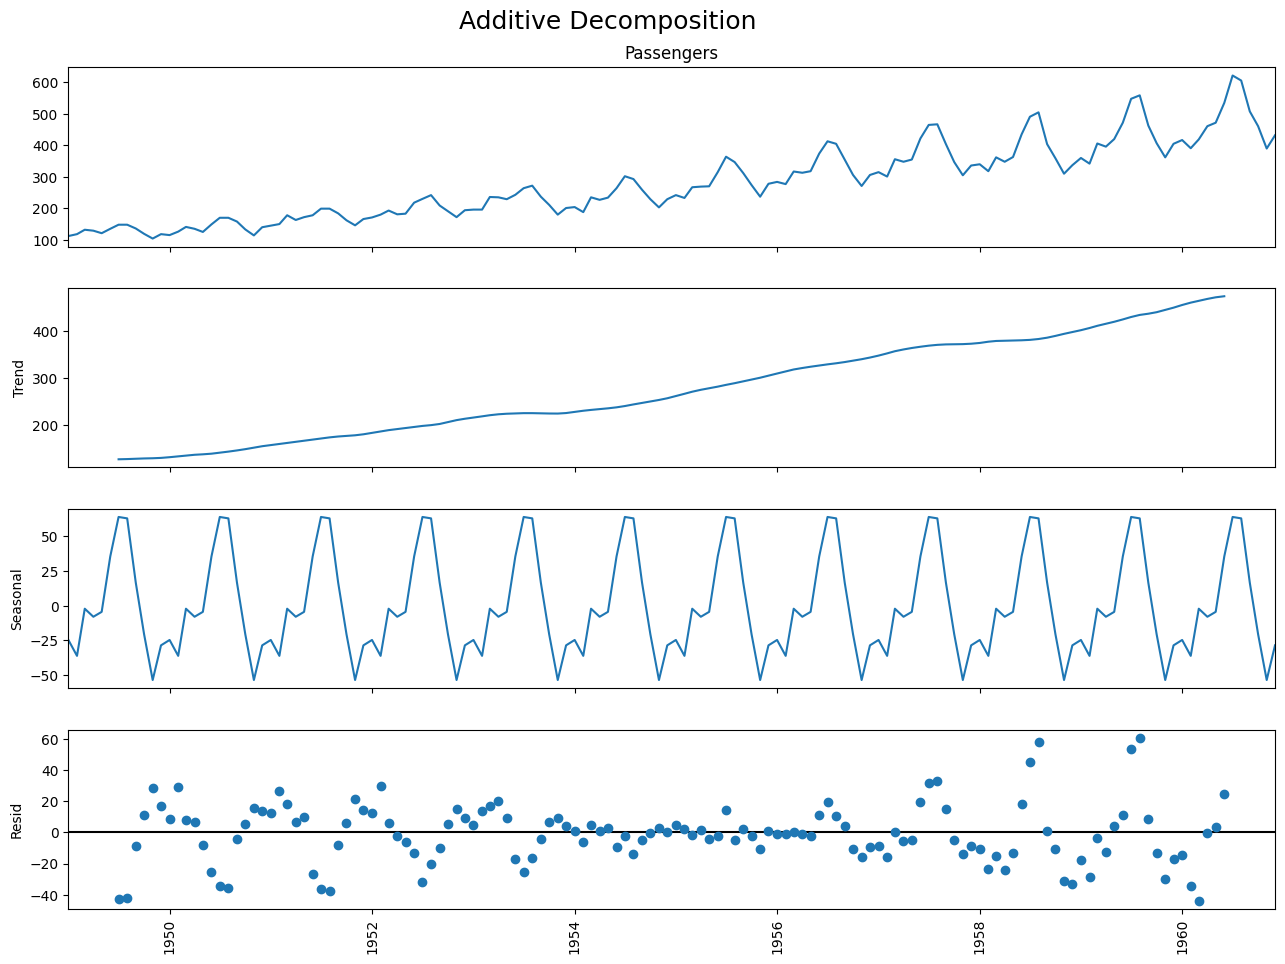

In [9]:
# Applying Additive Decomposition
additive_result = seasonal_decompose(df["Passengers"], model="additive", period = 12)

fig = additive_result.plot()
fig.set_size_inches(14, 10)
plt.suptitle("Additive Decomposition", fontsize=18)
plt.xticks(rotation=90)
plt.show()

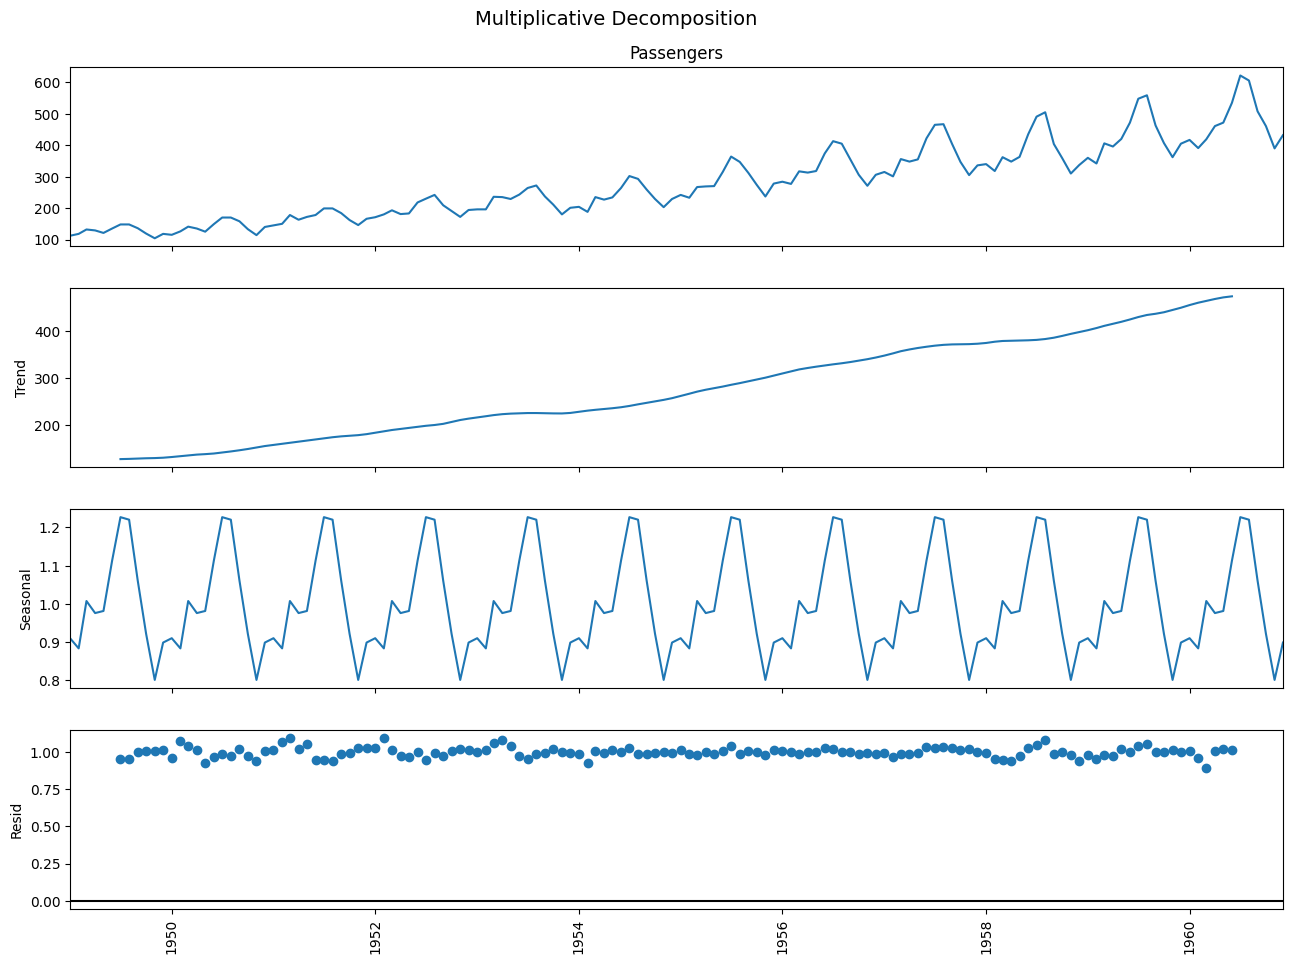

In [10]:
# Applying Multiplicative Decomposition
multiplicative_result = seasonal_decompose(df["Passengers"], model='multiplicative', period = 12)

fig = multiplicative_result.plot()
fig.set_size_inches(14, 10)
plt.suptitle("Multiplicative Decomposition", fontsize=14)
plt.xticks(rotation = 90)
plt.show()